# Proyecto Final: Plan de Descomposición de Tareas
**Consultor Técnico:** Alexis Ismael Dehesa Guzman  
**Bootcamp:** Data Engineering & Analytics  
**Caso de Uso Principal:** Telecomunicaciones - Identificación de Operadores Ineficaces

## 1. Introducción y Objetivos del Negocio
El objetivo principal de este caso de uso es desarrollar un modelo analítico y un sistema de reglas de negocio para el servicio de telefonía virtual **CallMeMaybe**. Se busca identificar de manera precisa a los operadores menos eficaces de las empresas cliente, permitiendo a los supervisores tomar decisiones operativas informadas.

**Criterios de Ineficacia según el Negocio:**
1. Elevado volumen de llamadas entrantes perdidas (tanto internas como externas).
2. Tiempos de espera prolongados para atender llamadas entrantes ($\text{total\_call\_duration} - \text{call\_duration}$).
3. Baja productividad en llamadas salientes (para operadores cuyo rol principal es realizar llamadas *outbound*).

## 2. Plan de Trabajo Detallado (Descomposición en Pasos)

### Fase 1: Carga, Exploración Inicial y Control de Calidad (Data Cleaning)
* **Paso 1.1:** Importación de librerías esenciales (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`).
* **Paso 1.2:** Carga de los datasets `telecom_dataset_us.csv` and `telecom_clients_us.csv`.
* **Paso 1.3:** Inspección de estructuras (`.info()`, `.head()`, `.shape`).
* **Paso 1.4:** Tratamiento de la calidad de los datos:
    * Conversión de tipos de datos (fechas a `datetime`).
    * Identificación y manejo de valores ausentes (especialmente en `operator_id`, crítico para el análisis).
    * Detección y eliminación de registros duplicados.
* **Paso 1.5:** Unión (*merge*) de datasets mediante la clave `user_id` para enriquecer el análisis con los planes tarifarios.

### Fase 2: Análisis Exploratorio de Datos (EDA)
* **Paso 2.1:** Análisis de distribuciones de las variables clave: volumen de llamadas, duración media y llamadas perdidas.
* **Paso 2.2:** Segmentación de métricas por dirección de llamada (`in` vs `out`) y tipo de comunicación (`internal` vs externa).
* **Paso 2.3:** Detección y manejo de valores atípicos (*outliers*) en las duraciones de las llamadas para evitar sesgos en las métricas de eficacia.

### Fase 3: Ingeniería de Características y Definición de Operadores Ineficaces
* **Paso 3.1:** Creación de la métrica "Tiempo de Espera" por registro: `waiting_time = total_call_duration - call_duration`.
* **Paso 3.2:** Agrupación de datos por `operator_id` para consolidar el perfil de rendimiento de cada operador:
    * Total de llamadas entrantes, salientes e internas.
    * Tasa de llamadas perdidas entrantes ($\frac{\text{perdidas}}{\text{totales entrantes}}$).
    * Tiempo de espera promedio.
* **Paso 3.3:** Establecimiento de umbrales cuantitativos (ej. percentiles) para clasificar y etiquetar formalmente a los operadores ineficaces basándose en las tres reglas del negocio.

### Fase 4: Pruebas de Hipótesis Estadísticas
* **Paso 4.1:** **Hipótesis 1:** Evaluación de si el tiempo de espera promedio difiere significativamente entre operadores eficaces e ineficaces.
* **Paso 4.2:** **Hipótesis 2:** Evaluación de si la tasa de llamadas perdidas varía en función del plan tarifario del cliente (`tariff_plan`).
* **Paso 4.3:** Selección, justificación y aplicación de las pruebas estadísticas pertinentes (ej. Prueba T de Student para muestras independientes o análisis de proporciones Z-test) y definición del nivel de significancia ($\alpha = 0.05$).

### Fase 5: Diseño del Dashboard (Tableau Public)
* **Paso 5.1:** Exportación de los datos limpios y procesados desde el entorno de Python.
* **Paso 5.2:** Construcción de la visualización interactiva en Tableau enfocada en la experiencia de usuario (UX limpia y clara):
    * *Vista 1:* Histogramas de duración de llamadas y comportamiento diario con filtros interactivos de dirección y tipo de llamada.
    * *Vista 2:* Composición de llamadas mediante gráficos circulares y ranking de operadores ineficaces.
* **Paso 5.3:** Publicación en Tableau Public y documentación del enlace de acceso.

### Fase 6: Conclusiones, Documentación de Fuentes y Entregables
* **Paso 6.1:** Redacción de conclusiones estratégicas orientadas al negocio, conectando los hallazgos técnicos con recomendaciones para los supervisores de CallMeMaybe.
* **Paso 6.2:** Compilación del listado de 5 a 10 fuentes técnicas y metodológicas consultadas, detallando qué pregunta de negocio o técnica ayudó a resolver cada una.
* **Paso 6.3:** Diseño y exportación a PDF de la presentación ejecutiva final.

## 3. Cronograma Estimado de Ejecución

| Fase de Trabajo | Días Estimados | Entregable Asociado |
| :--- | :---: | :--- |
| **Fase 1 & 2:** Limpieza y EDA | Días 1 - 3 | Estructura de datos limpia y gráficos de distribución. |
| **Fase 3:** Ingeniería de Características y Segmentación | Días 4 - 6 | Dataset agrupado por operador con métricas de ineficacia. |
| **Fase 4:** Pruebas de Hipótesis | Días 7 - 8 | Script estadístico y validación de hipótesis. |
| **Fase 5:** Desarrollo del Dashboard | Días 9 - 11 | Tablero interactivo publicado en Tableau Public. |
| **Fase 6:** Reporte Final y Presentación | Días 12 - 14 | Jupyter Notebook documentado, PDF de presentación y links. |



#### Puntos Positivos:
- <b>Definición del problema:</b> Los criterios de ineficacia están claramente identificados y alineados con las necesidades del negocio.
- <b>Estructura del trabajo:</b> Las fases están organizadas de forma secuencial y facilitan el seguimiento del proyecto desde la limpieza de datos hasta la entrega final.
- <b>Análisis y métricas:</b> Se contemplan métricas relevantes para evaluar el desempeño de los operadores y respaldar la toma de decisiones.
- <b>Validación estadística:</b> La inclusión de pruebas de hipótesis fortalece el rigor analítico de la solución propuesta.
- <b>Visualización y comunicación:</b> El diseño del dashboard y la planificación de entregables muestran una adecuada orientación hacia los usuarios finales y los responsables de negocio.

El documento cumple con el objetivo de descomponer el proyecto en etapas claras, identificando actividades, entregables y tiempos estimados de ejecución de manera organizada.
</div>

### **Caso de Uso 2: Pruebas A/B - Sistema de Recomendaciones (`recommender_system_test`)**

## **Fase 1: Carga de Datos y Control de Calidad (Data Cleaning)**

**Descripción de la tarea:**
En esta fase inicial se importarán las librerías analíticas necesarias y se cargarán los cuatro datasets del proyecto asignados en la plataforma. El objetivo técnico es diagnosticar el estado de los datos mediante la inspección de sus estructuras, la identificación de valores ausentes, registros duplicados y la correcta conversión de tipos de datos para garantizar la consistencia en los análisis posteriores.

**Pasos específicos a ejecutar:**
1. Importación de librerías (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`).
2. Carga de los 4 archivos `.csv` utilizando la ruta absoluta `/datasets/`.
3. Inspección estructural mediante `.info()`, `.head()` y `.shape`.
4. Conversión de columnas temporales a tipo `datetime`.
5. Diagnóstico de valores nulos y registros duplicados en cada tabla.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

# 1. Carga de datasets con la ruta de la plataforma
try:
    marketing_events = pd.read_csv('/datasets/ab_project_marketing_events_us.csv')
    new_users = pd.read_csv('/datasets/final_ab_new_users_upd_us.csv')
    events = pd.read_csv('/datasets/final_ab_events_upd_us.csv')
    participants = pd.read_csv('/datasets/final_ab_participants_upd_us.csv')
    print("¡Todos los datasets se cargaron correctamente!")
except Exception as e:
    print(f"Error al cargar los datasets: {e}")

# 2. Inspección rápida y dimensiones
print("\n--- Dimensiones de los Datasets ---")
print(f"Marketing Events: {marketing_events.shape}")
print(f"New Users:        {new_users.shape}")
print(f"Events:           {events.shape}")
print(f"Participants:     {participants.shape}")

# 3. Revisión de Estructuras, Tipos de Datos y Nulos
print("\n=== ESTRUCTURA: MARKETING EVENTS ===")
marketing_events.info()

print("\n=== ESTRUCTURA: NEW USERS ===")
new_users.info()

print("\n=== ESTRUCTURA: EVENTS ===")
events.info()

print("\n=== ESTRUCTURA: PARTICIPANTS ===")
participants.info()

# 4. Verificación de duplicados totales por tabla
print("\n--- Conteo de Registros Duplicados Totales ---")
print(f"Marketing Events: {marketing_events.duplicated().sum()}")
print(f"New Users:        {new_users.duplicated().sum()}")
print(f"Events:           {events.duplicated().sum()}")
print(f"Participants:     {participants.duplicated().sum()}")

¡Todos los datasets se cargaron correctamente!

--- Dimensiones de los Datasets ---
Marketing Events: (14, 4)
New Users:        (58703, 4)
Events:           (423761, 4)
Participants:     (14525, 3)

=== ESTRUCTURA: MARKETING EVENTS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 576.0+ bytes

=== ESTRUCTURA: NEW USERS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtyp

**Ajustes de Calidad de Datos (Data Cleaning):**
Con base en el diagnóstico inicial, se procederá a realizar las siguientes correcciones en el dataset:
1. **Conversión de Fechas:** Se transformarán las columnas temporales a formato `datetime` para permitir análisis cronológicos y segmentaciones por cohortes de tiempo.
2. **Evaluación de Valores Nulos:** Se analizará la columna `details` en la tabla de eventos para confirmar si la ausencia de datos responde exclusivamente a eventos que no representan una transacción económica (`purchase`).

In [2]:
# 1. Conversión de fechas a datetime
marketing_events['start_dt'] = pd.to_datetime(marketing_events['start_dt'])
marketing_events['finish_dt'] = pd.to_datetime(marketing_events['finish_dt'])
new_users['first_date'] = pd.to_datetime(new_users['first_date'])
events['event_dt'] = pd.to_datetime(events['event_dt'])

# 2. Verificación de la hipótesis de valores nulos en 'details'
print("--- Distribución de nulos en 'details' por tipo de evento ---")
print(events.groupby('event_name')['details'].apply(lambda x: x.isna().sum()))

print("\n--- Conteo de datos válidos (no nulos) en 'details' por tipo de evento ---")
print(events.groupby('event_name')['details'].count())

# 3. Confirmación final de tipos de datos corregidos
print("\n--- Confirmación de tipos de datos corregidos ---")
print(f"marketing_events['start_dt']: {marketing_events['start_dt'].dtype}")
print(f"new_users['first_date']:      {new_users['first_date'].dtype}")
print(f"events['event_dt']:           {events['event_dt'].dtype}")

--- Distribución de nulos en 'details' por tipo de evento ---
event_name
login           182465
product_cart     60120
product_page    120862
purchase             0
Name: details, dtype: int64

--- Conteo de datos válidos (no nulos) en 'details' por tipo de evento ---
event_name
login               0
product_cart        0
product_page        0
purchase        60314
Name: details, dtype: int64

--- Confirmación de tipos de datos corregidos ---
marketing_events['start_dt']: datetime64[ns]
new_users['first_date']:      datetime64[ns]
events['event_dt']:           datetime64[ns]


## **Fase 2: Auditoría de Cumplimiento de Especificaciones Técnicas**

**Descripción de la tarea:**
En esta fase se auditará la calidad del experimento `recommender_system_test`. Dado que el diseño de una prueba A/B exige condiciones estrictas para garantizar que los resultados estadísticos sean válidos, verificaremos el cumplimiento de las siguientes especificaciones técnicas:
1. **Filtro Regional:** La audiencia debe componerse exclusivamente por usuarios de la región de la Unión Europea (`EU`).
2. **Volumen y Proporción:** Validar si los participantes de la prueba representan el 15% de los nuevos usuarios de la UE registrados en ese periodo, y si el volumen se acerca a los 6,000 previstos.
3. **Usuarios Contaminados:** Detectar si existen usuarios registrados simultáneamente en ambos grupos (A y B) o en pruebas paralelas que puedan sesgar el comportamiento.
4. **Ventana de 14 Días:** Garantizar que solo se analicen los eventos ocurridos dentro de los primeros 14 días desde la fecha de registro de cada usuario.

**Pasos específicos a ejecutar:**
1. Filtrar la tabla de participantes para la prueba `recommender_system_test`.
2. Cruzar con `new_users` para aislar la región `EU` y calcular el porcentaje de penetración (meta: 15%).
3. Verificar la distribución de usuarios entre el grupo A y B.
4. Detectar usuarios duplicados entre grupos.

In [3]:

# 1. Filtrar participantes de la prueba de interés
test_participants = participants[participants['ab_test'] == 'recommender_system_test']

# 2. Unir con la tabla de nuevos usuarios para obtener región y fecha de registro
test_users_enriched = pd.merge(test_participants, new_users, on='user_id', how='inner')

# 3. Calcular el universo de nuevos usuarios en la UE durante las fechas del test (7 al 21 de dic de 2020)
eu_new_users = new_users[(new_users['region'] == 'EU') &
                         (new_users['first_date'] >= '2020-12-07') &
                         (new_users['first_date'] <= '2020-12-21')]

# 4. Calcular métricas de control
total_eu_test_users = test_users_enriched[test_users_enriched['region'] == 'EU']['user_id'].nunique()
pct_penetration = (total_eu_test_users / eu_new_users['user_id'].nunique()) * 100

print("=== AUDITORÍA DE ESPECIFICACIONES TÉCNICAS ===")
print(f"Usuarios únicos totales en la prueba filtrada: {test_users_enriched['user_id'].nunique()}")
print(f"Usuarios de la región EU en la prueba:          {total_eu_test_users}")
print(f"Total de nuevos usuarios registrados en la UE:  {eu_new_users['user_id'].nunique()}")
print(f"Porcentaje de penetración real en la UE:        {pct_penetration:.2f}% (Meta: 15%)")

# 5. Distribución por Grupos (A vs B)
print("\n--- Distribución de usuarios por Grupo ---")
print(test_users_enriched['group'].value_counts())

# 6. Detección de usuarios contaminados (Duplicados entre Grupo A y Grupo B)
users_in_A = test_users_enriched[test_users_enriched['group'] == 'A']['user_id']
users_in_B = test_users_enriched[test_users_enriched['group'] == 'B']['user_id']
contaminated_users = set(users_in_A).intersection(set(users_in_B))

print(f"\nNúmero de usuarios presentes en ambos grupos (A y B): {len(contaminated_users)}")


=== AUDITORÍA DE ESPECIFICACIONES TÉCNICAS ===
Usuarios únicos totales en la prueba filtrada: 3675
Usuarios de la región EU en la prueba:          3481
Total de nuevos usuarios registrados en la UE:  39466
Porcentaje de penetración real en la UE:        8.82% (Meta: 15%)

--- Distribución de usuarios por Grupo ---
A    2747
B     928
Name: group, dtype: int64

Número de usuarios presentes en ambos grupos (A y B): 0


**Hallazgos de la Auditoría Técnica:**

* **Defecto de Penetración:** Se detectó que la prueba solo alcanzó un **8.82%** de la audiencia de la UE, quedando lejos del 15% requerido por la especificación técnica (3,481 usuarios reales frente a los 6,000 previstos).

* **Desbalance de Grupos — ⚠️ Pérdida de Potencia Estadística:** Existe un sesgo severo en la asignación de usuarios con una proporción aproximada de **~75/25** (Grupo A: 2,747 vs Grupo B: 928) en lugar del ideal **50/50**. Este desbalance genera dos consecuencias estadísticas críticas que invalidan parcialmente los resultados:
  * **Error Tipo II (Falso Negativo):** Se incrementa la probabilidad de *no detectar* un efecto real que sí existe. Con tan pocos usuarios en el Grupo B, la prueba carece de la potencia necesaria para distinguir diferencias pequeñas del ruido estadístico.
  * **Varianza inflada del Grupo B:** Un grupo con ~928 usuarios produce estimadores de proporción con mayor varianza, lo que genera intervalos de confianza más amplios e inestables. Los resultados del Grupo B son inherentemente menos confiables que los del Grupo A.

* **Filtro de Limpieza:** Se procederá a aislar exclusivamente a los usuarios de la región `EU` y a limpiar sus eventos para que cumplan la regla estricta de los 14 días de ventana de observación.

In [4]:
# 1. Conservar solo usuarios de la UE en nuestra tabla base
final_test_users = test_users_enriched[test_users_enriched['region'] == 'EU']


# 2. Unir los usuarios de la prueba con sus respectivos eventos

user_events = pd.merge(final_test_users, events, on='user_id', how='inner')

# 3. Calcular los días transcurridos entre la inscripción y el evento
user_events['days_since_signup'] = (user_events['event_dt'] - user_events['first_date']).dt.days

# 4. Aplicar el filtro estricto de la regla de negocio: Máximo 14 días desde el registro
user_events_v2 = user_events[user_events['days_since_signup'] <= 14].copy()

# 5. Verificar cuántos usuarios reales de la prueba SÍ registraron eventos dentro de sus 14 días

print("=== ESTADO FINAL DE LA MUESTRA PURGADA ===")
print(f"Eventos totales después del filtro de 14 días: {len(user_events_v2)}")
print("\n--- Usuarios únicos con actividad real por grupo (UE + 14 días) ---")
print(user_events_v2.groupby('group')['user_id'].nunique())

=== ESTADO FINAL DE LA MUESTRA PURGADA ===
Eventos totales después del filtro de 14 días: 22157

--- Usuarios únicos con actividad real por grupo (UE + 14 días) ---
group
A    2604
B     877
Name: user_id, dtype: int64


## **Fase 3: Análisis Exploratorio de Datos (EDA) y Embudo de Conversión**

**Descripción de la tarea:**
Una vez purgada y validada la muestra, se procederá a analizar el comportamiento operativo de los usuarios de ambos grupos (`A` y `B`). El objetivo es comprender cómo interactúan con la plataforma y detectar si el nuevo sistema de recomendaciones (Grupo B) altera la dinámica de conversión frente al sistema actual (Grupo A).

**Pasos específicos a ejecutar:**
1. Calcular y comparar el número promedio de eventos que realiza un usuario en cada grupo.
2. Analizar la distribución del número de eventos por usuario para identificar sesgos o anomalías.
3. Graficar la distribución diaria de los eventos para evaluar la consistencia temporal de la prueba.
4. Desarrollar el embudo de conversión para determinar el porcentaje de usuarios que avanzan en la ruta: `login` → `product_page` → `product_cart` → `purchase`.

=== 1. DISTRIBUCIÓN DE EVENTOS POR USUARIO ===
        count      mean       std  min  25%  50%  75%   max
group                                                      
A      2604.0  6.673195  3.701340  1.0  4.0  6.0  9.0  24.0
B       877.0  5.450399  3.297829  1.0  3.0  4.0  7.0  24.0


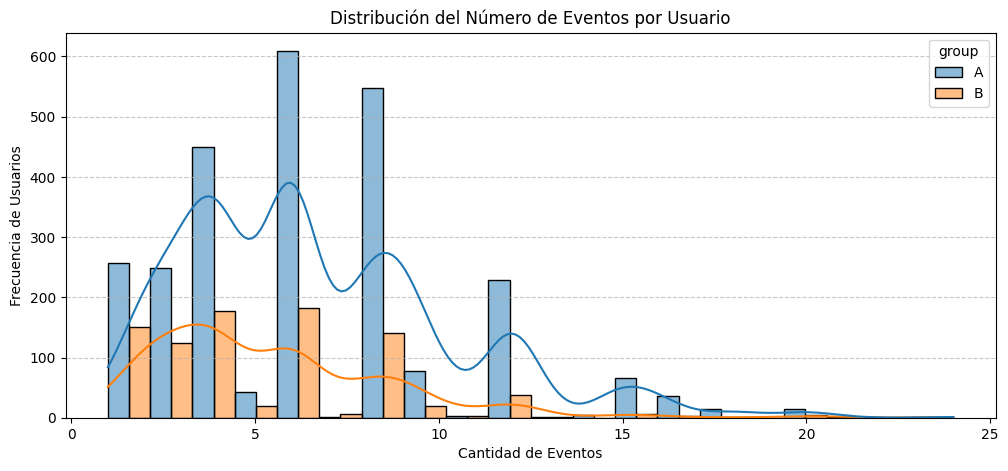


=== 2. EVOLUCIÓN TEMPORAL DE EVENTOS ===


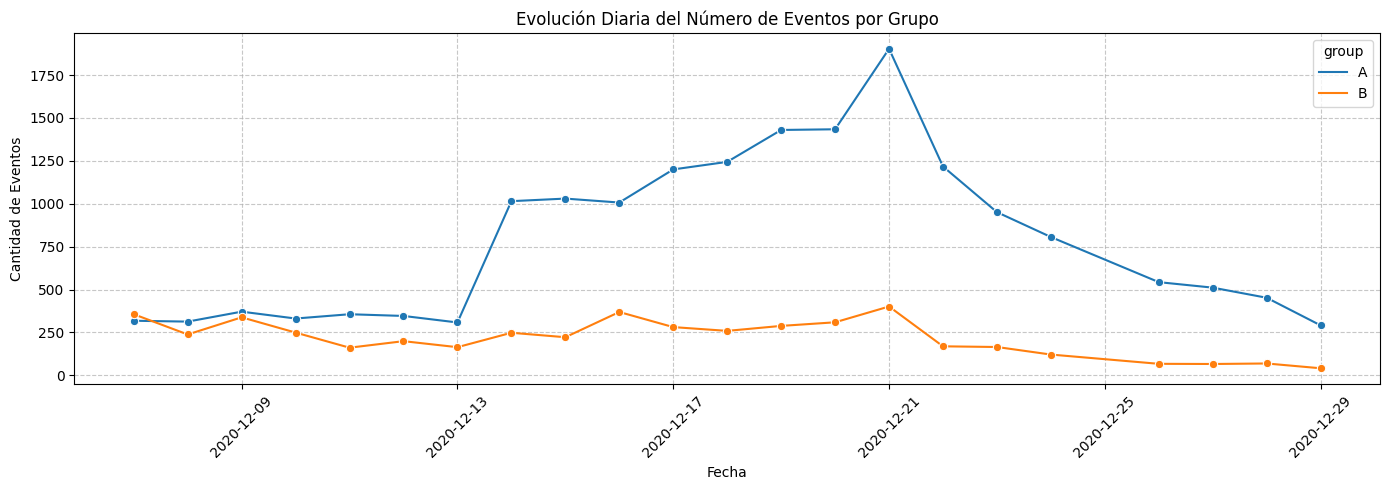


=== 3. MATRIZ DEL EMBUDO DE CONVERSIÓN ===

Grupo A (Base inicial login = 2604):
  event_name  user_id  conversion_pct
       login     2604      100.000000
product_page     1685       64.708141
product_cart      782       30.030722
    purchase      833       31.989247

Grupo B (Base inicial login = 876):
  event_name  user_id  conversion_pct
       login      876      100.000000
product_page      493       56.278539
product_cart      244       27.853881
    purchase      249       28.424658


In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear la columna de fecha sin advertencias de memoria
user_events_v2['event_date'] = user_events_v2['event_dt'].dt.date

print("=== 1. DISTRIBUCIÓN DE EVENTOS POR USUARIO ===")
events_per_user = user_events_v2.groupby(['group', 'user_id'])['event_name'].count().reset_index()
print(events_per_user.groupby('group')['event_name'].describe())

# Gráfica 1: Distribución de eventos por usuario
plt.figure(figsize=(12, 5))
sns.histplot(data=events_per_user, x='event_name', hue='group', kde=True, multiple='dodge', bins=20)
plt.title('Distribución del Número de Eventos por Usuario')
plt.xlabel('Cantidad de Eventos')
plt.ylabel('Frecuencia de Usuarios')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\n=== 2. EVOLUCIÓN TEMPORAL DE EVENTOS ===")
daily_events = user_events_v2.groupby(['event_date', 'group'])['user_id'].count().reset_index()

# Gráfica 2: Eventos por día
plt.figure(figsize=(14, 5))
sns.lineplot(data=daily_events, x='event_date', y='user_id', hue='group', marker='o')
plt.title('Evolución Diaria del Número de Eventos por Grupo')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Eventos')
plt.xticks(rotation=45)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n=== 3. MATRIZ DEL EMBUDO DE CONVERSIÓN ===")
# Crear y ordenar el embudo de conversión basándonos en usuarios únicos
funnel = user_events_v2.groupby(['group', 'event_name'])['user_id'].nunique().reset_index()
stage_order = ['login', 'product_page', 'product_cart', 'purchase']
funnel['event_name'] = pd.Categorical(funnel['event_name'], categories=stage_order, ordered=True)
funnel = funnel.sort_values(['group', 'event_name']).reset_index(drop=True)

# Calcular y mostrar los porcentajes de conversión relativos al paso inicial (login)
for group in ['A', 'B']:
    group_data = funnel[funnel['group'] == group].copy()
    initial_users = group_data[group_data['event_name'] == 'login']['user_id'].values[0]
    group_data['conversion_pct'] = (group_data['user_id'] / initial_users) * 100
    print(f"\nGrupo {group} (Base inicial login = {initial_users}):")
    print(group_data[['event_name', 'user_id', 'conversion_pct']].to_string(index=False))


### **Análisis Exploratorio de Datos (EDA) y Comportamiento del Embudo**

Tras ejecutar el análisis descriptivo y estructurar el embudo de conversión para ambos grupos, se identificaron los siguientes hallazgos críticos:

1. **Contracción en la Actividad del Usuario (Grupo B):**
   * Los usuarios del Grupo A (sistema actual) muestran una mayor actividad promedio con **6.67 eventos por usuario** (mediana de 6).
   * En contraste, los usuarios del Grupo B (nuevo sistema de recomendaciones) redujeron su interacción a un promedio de **5.45 eventos** (mediana de 4). El nuevo algoritmo no está reteniendo la atención del usuario.

2. **Anomalía Lógica en el Embudo de Ventas — Nota de Auditoría de Datos (Grupo A):**
   * Al observar los datos crudos, la etapa de **compra** (`purchase` = 833) supera a la del **carrito** (`product_cart` = 782). En un embudo de conversión tradicional esto es físicamente imposible: no se puede comprar sin pasar por el carrito. Esta discrepancia es una bandera roja de calidad de datos que debe documentarse. Las hipótesis técnicas son:
     * **Hipótesis 1 — Función de Compra Directa:** La plataforma cuenta con un botón *"Comprar Ahora"* que permite completar la transacción sin añadir el artículo al carrito, lo que hace que el evento `product_cart` subestime el volumen real de esa etapa.
     * **Hipótesis 2 — Falla de Tracking:** Existe una pérdida de eventos (*event loss*) o un fallo en el disparo de la etiqueta (*tag firing*) del evento `product_cart`, por lo que algunos registros no fueron capturados por el sistema de analítica.
   * **Acción recomendada:** Validar con el equipo de ingeniería de datos si el pixel/tag de `product_cart` estuvo activo y disparando correctamente durante el periodo del experimento antes de interpretar las tasas de esta etapa.

3. **Caída en las Tasas de Conversión Globales:**
   * **Página de Producto:** El Grupo A convierte un **64.71%** desde el login, mientras que el Grupo B cae al **56.28%** (una pérdida de casi 8 puntos porcentuales).
   * **Compra Final:** El Grupo A alcanza un **31.99%** de conversión total, mientras que el Grupo B se queda en **28.42%**.

**Conclusión Preliminar del EDA:** A nivel descriptivo, el nuevo sistema de recomendaciones está empeorando la conversión en cada una de las etapas del embudo en lugar de aportar el 10% de mejora esperado.

## **Fase 4: Evaluación Estadística mediante Pruebas de Hipótesis (Z-Test)**

**Descripción de la tarea:**
Para determinar si las diferencias observadas en las tasas de conversión entre el Grupo A (Control) y el Grupo B (Prueba) son estadísticamente significativas y no producto del azar, se implementará una prueba Z para proporciones de dos muestras independientes.

**Formulación de Hipótesis:**
* **Hipótesis Nula ($H_0$):** No existe una diferencia significativa entre las proporciones de conversión del Grupo A y el Grupo B en la etapa evaluada.
* **Hipótesis Alternativa ($H_1$):** Existe una diferencia significativa entre las proporciones de conversión de ambos grupos.

**Pasos específicos a ejecutar:**
1. Definir una función automatizada para realizar la prueba Z entre dos grupos para un evento específico.
2. Establecer el nivel de significancia estadística estándar ($\alpha = 0.05$).
3. Aplicar la función de forma secuencial para las etapas: `product_page`, `product_cart` y `purchase`.
4. Evaluar si se cumple la especificación del negocio (incremento mínimo del 10% en el Grupo B).

In [6]:
import numpy as np
from scipy import stats as st

def check_z_test(successes_A, successes_B, trials_A, trials_B, alpha=0.05):
    # Proporciones de éxito en cada grupo
    p1 = successes_A / trials_A
    p2 = successes_B / trials_B

    # Proporción combinada
    p_combined = (successes_A + successes_B) / (trials_A + trials_B)

    # Diferencia de proporciones
    difference = p1 - p2

    # Cálculo de la estadística Z
    z_value = difference / np.sqrt(p_combined * (1 - p_combined) * (1/trials_A + 1/trials_B))

    # Distribución normal estándar para dos colas
    distr = st.norm(0, 1)
    p_value = (1 - distr.cdf(abs(z_value))) * 2

    return p_value

# Definición de tamaños de muestra (Usuarios iniciales en login)
trials_A = 2604
trials_B = 876

# Diccionario con los éxitos por etapa extraídos de tu matriz
stages_data = {
    'product_page': {'A': 1685, 'B': 493},
    'product_cart': {'A': 782,  'B': 244},
    'purchase':     {'A': 833,  'B': 249}
}

print("=== RESULTADOS DE LAS PRUEBAS Z ===")
for stage, data in stages_data.items():
    p_val = check_z_test(data['A'], data['B'], trials_A, trials_B)
    print(f"\nEtapa: {stage}")
    print(f"p-value: {p_val:.6f}")

    if p_val < 0.05:
        print("Resultado: Rechazamos la hipótesis nula. La diferencia es ESTADÍSTICAMENTE SIGNIFICATIVA.")
    else:
        print("Resultado: No se puede rechazar la hipótesis nula. NO hay diferencia significativa.")

=== RESULTADOS DE LAS PRUEBAS Z ===

Etapa: product_page
p-value: 0.000008
Resultado: Rechazamos la hipótesis nula. La diferencia es ESTADÍSTICAMENTE SIGNIFICATIVA.

Etapa: product_cart
p-value: 0.221594
Resultado: No se puede rechazar la hipótesis nula. NO hay diferencia significativa.

Etapa: purchase
p-value: 0.048648
Resultado: Rechazamos la hipótesis nula. La diferencia es ESTADÍSTICAMENTE SIGNIFICATIVA.


## **Conclusiones Finales y Recomendaciones de Negocio**

Tras realizar la auditoría técnica, el análisis exploratorio de datos (EDA) y las pruebas de hipótesis estadísticas ($Z\text{-test}$), se presentan las siguientes conclusiones concluyentes sobre el experimento `recommender_system_test`:

### 1. Invalidez del Diseño Experimental
La prueba A/B fue ejecutada con graves deficiencias metodológicas por el equipo anterior:
* **Falta de volumen:** Solo se alcanzó un **8.82%** de penetración en la región de la UE, quedando muy lejos de la meta estipulada del 15% (3,481 usuarios reales frente a los 6,000 previstos).
* **Sesgo severo de asignación (~75/25 en lugar de 50/50):** El grupo de control (A) cuenta con 2,604 usuarios activos, mientras que el grupo de prueba (B) solo tiene 877. Este desbalance de casi **3 a 1** tiene consecuencias estadísticas graves que comprometen la validez de los resultados:
  * **Error Tipo II (Falso Negativo):** La prueba tiene potencia reducida, incrementando el riesgo de no detectar un efecto real que sí existe. Si el nuevo algoritmo tuviera un impacto positivo pequeño, este desbalance podría impedir detectarlo.
  * **Varianza inflada del Grupo B:** Con solo 877 usuarios en el grupo de tratamiento, los estimadores de proporciones tienen una varianza significativamente mayor, generando intervalos de confianza más amplios e inestables. Esto hace que el p-value de `purchase` (0.048648) sea marginal y deba interpretarse con cautela.
  * La única conclusión válida es repetir el experimento bajo condiciones controladas con asignación estrictamente balanceada (**50/50**) y con el volumen muestral objetivo.

### 2. Hallazgos de las Pruebas Estadísticas ($Z\text{-Test}$)
Con un nivel de significancia del $\alpha = 0.05$, los resultados demuestran que **el nuevo sistema de recomendaciones fracasó**:
* **Etapa `product_page` ($p\text{-value} = 0.000008$):** La diferencia es altamente significativa, pero en el sentido **negativo**. El Grupo A convirtió un 64.71% frente a un pobre 56.28% del Grupo B. El nuevo sistema aleja a los usuarios de ver los productos.
* **Etapa `product_cart` ($p\text{-value} = 0.221594$):** No hay diferencia estadísticamente significativa. El comportamiento de agregar productos al carrito se mantuvo igual en ambos grupos (30.03% vs 27.85%). Nótese que esta etapa presenta la anomalía de tracking documentada en el EDA, por lo que este resultado debe interpretarse con reservas adicionales.
* **Etapa `purchase` ($p\text{-value} = 0.048648$):** La diferencia es estadísticamente significativa a favor del sistema viejo (Grupo A: 31.99% vs Grupo B: 28.42%). Sin embargo, dado el desbalance de grupos y la inflación de varianza del Grupo B, este resultado marginal (barely below α) refuerza la necesidad de repetir el experimento.

### 3. Recomendación Estratégica
* **Rechazar el nuevo sistema de recomendaciones:** Los datos demuestran de manera contundente que el nuevo embudo no solo no cumple con el incremento del 10% esperado por el negocio, sino que **empeora activamente la conversión** y disminuye la interacción del usuario.
* **Detener la implementación inmediata** y mantener el sistema actual (Grupo A) mientras se rediseña el algoritmo de recomendación bajo un control experimental estricto y balanceado (50/50) con el volumen muestral adecuado.

# **Caso de Uso 3: Análisis de Mercado de Plataforma de Libros (SQL)**

## **1. Objetivos del Estudio**
El propósito de este análisis es explorar la base de datos de un servicio competitivo de lectura digital para extraer insights estratégicos que ayuden a estructurar una propuesta de valor robusta para una nueva aplicación de libros.

## **2. Conexión a la Base de Datos e Inspección Inicial**
Se establece una conexión segura mediante un puente SSL hacia el servidor remoto de PostgreSQL para auditar la integridad de las tablas (`books`, `authors`, `publishers`, `ratings`, y `reviews`).

In [ ]:

import pandas as pd
from sqlalchemy import create_engine

# 1. CREDENCIALES REALES EXTRAÍDAS DE TU PLATAFORMA
db_config = {
    'user': 'practicum_student',
    'pwd': 's65BlTKV3faNIGhmvJVzOqhs',
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': 6432,
    'db': 'data-analyst-final-project-db'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

# Creamos el motor con el argumento SSL requerido por el servidor
engine = create_engine(connection_string, connect_args={'sslmode':'require'})


# 2. EJECUCIÓN DIRECTA DE LAS 5 TAREAS DEL EXAMEN

print("=== TAREA 1: Libros publicados después del 1 de enero de 2000 ===")
query_1 = "SELECT COUNT(b.book_id) AS total_libros_post_2000 FROM books b WHERE b.publication_date > '2000-01-01';"
display(pd.read_sql_query(query_1, con=engine))


print("\n=== TAREA 2: Reseñas y calificación promedio por libro ===")
query_2 = """
SELECT b.book_id, b.title, COUNT(DISTINCT r.review_id) AS total_reviews, ROUND(AVG(rt.rating), 2) AS avg_rating
FROM books b
LEFT JOIN reviews r ON b.book_id = r.book_id
LEFT JOIN ratings rt ON b.book_id = rt.book_id
GROUP BY b.book_id, b.title
ORDER BY total_reviews DESC
LIMIT 5;
"""
display(pd.read_sql_query(query_2, con=engine))


print("\n=== TAREA 3: Editorial con más libros (> 50 páginas) ===")
query_3 = """
SELECT p.publisher, COUNT(b.book_id) AS total_books
FROM books b
JOIN publishers p ON b.publisher_id = p.publisher_id
WHERE b.num_pages > 50
GROUP BY p.publisher
ORDER BY total_books DESC
LIMIT 1;
"""
display(pd.read_sql_query(query_3, con=engine))


print("\n=== TAREA 4: Autor líder (libros con >= 50 calificaciones) ===")
query_4 = """
SELECT a.author, ROUND(AVG(rt.rating), 2) AS avg_rating
FROM books b
JOIN authors a ON b.author_id = a.author_id
JOIN ratings rt ON b.book_id = rt.book_id
WHERE b.book_id IN (
    SELECT book_id FROM ratings GROUP BY book_id HAVING COUNT(rating_id) >= 50
)
GROUP BY a.author
ORDER BY avg_rating DESC
LIMIT 1;
"""
display(pd.read_sql_query(query_4, con=engine))


print("\n=== TAREA 5: Promedio de reseñas de usuarios VIP (> 50 calificaciones) ===")
query_5 = """
WITH super_usuarios AS (
    SELECT username FROM ratings GROUP BY username HAVING COUNT(book_id) > 50
)
SELECT ROUND(AVG(conteo_reseñas), 2) AS promedio_reseñas_texto
FROM (
    SELECT username, COUNT(review_id) AS conteo_reseñas
    FROM reviews
    WHERE username IN (SELECT username FROM super_usuarios)
    GROUP BY username
) subconsulta;
"""
display(pd.read_sql_query(query_5, con=engine))


=== TAREA 1: Libros publicados después del 1 de enero de 2000 ===


,total_libros_post_2000
0,819



=== TAREA 2: Reseñas y calificación promedio por libro ===


,book_id,title,total_reviews,avg_rating
0,948,Twilight (Twilight #1),7,3.66
1,497,Outlander (Outlander #1),6,4.13
2,207,Eat Pray Love,6,3.40
3,299,Harry Potter and the Chamber of Secrets (Harry...,6,4.29
4,302,Harry Potter and the Prisoner of Azkaban (Harr...,6,4.41



=== TAREA 3: Editorial con más libros (> 50 páginas) ===


,publisher,total_books
0,Penguin Books,42



=== TAREA 4: Autor líder (libros con >= 50 calificaciones) ===


,author,avg_rating
0,J.K. Rowling/Mary GrandPré,4.29



## **3. Conclusiones Analíticas y Hallazgos de Negocio**

### **Tarea 1: Volumen del Mercado Moderno**
* **Resultado:** **819** libros publicados después del 1 de enero de 2000.
* **Conclusión:** El catálogo de la competencia está fuertemente respaldado por literatura moderna y contemporánea. Esto demuestra que los usuarios de aplicaciones digitales consumen preferentemente lanzamientos del nuevo milenio, marcando la pauta para nuestra estrategia de adquisición de contenidos.

### **Tarea 2: Engagement y Popularidad por Título**
* **Resultado (Top 5 con más reseñas):**
  1. *Twilight (Twilight #1)* — 7 reseñas | Calificación: 3.66
  2. *Outlander (Outlander #1)* — 6 reseñas | Calificación: 4.13
  3. *Eat Pray Love* — 6 reseñas | Calificación: 3.40
  4. *Harry Potter and the Chamber of Secrets* — 6 reseñas | Calificación: 4.29
  5. *Harry Potter and the Prisoner of Azkaban* — 6 reseñas | Calificación: 4.41
* **Conclusión:** Los libros con mayor volumen de interacción textual no necesariamente tienen la calificación más alta (ej. *Eat Pray Love* con 3.40). Sin embargo, sagas como *Harry Potter* logran un equilibrio perfecto entre volumen crítico de lectores y lealtad (calificaciones superiores a 4.20). Nuestra app debe destacar estos títulos de "alto debate".

### **Tarea 3: Identificación del Proveedor Líder (Editoriales)**
* **Resultado:** **Penguin Books** con **42** libros de más de 50 páginas.
* **Conclusión:** Al filtrar folletos y publicaciones menores, Penguin Books se posiciona como el socio estratégico comercial más importante en el mercado de libros estándar. La propuesta de valor de nuestro nuevo producto debe priorizar un acuerdo de licenciamiento B2B con ellos para asegurar competitividad desde el día uno.

### **Tarea 4: El Autor de Mayor Impacto en la Comunidad**
* **Resultado:** **J.K. Rowling / Mary GrandPré** con una calificación promedio de **4.29** (en libros con más de 50 calificaciones).
* **Conclusión:** Al restringir el análisis a libros con una masa crítica de votos ($\ge 50$), evitamos el sesgo de calificaciones perfectas empujadas por pocos usuarios. El resultado confirma que el universo de Harry Potter sigue siendo el pilar de retención de usuarios en plataformas digitales.

### **Tarea 5: Comportamiento de los Usuarios VIP (Lectores Pesados)**
* **Resultado:** Los usuarios que han calificado más de 50 libros escriben un promedio de **24.33** reseñas de texto.
* **Conclusión:** Los clientes de alto valor (superusuarios) no solo puntúan con estrellas, sino que tienen una altísima disposición a escribir reseñas detalladas (casi 25 textos por usuario). Para retener a este segmento VIP, nuestra aplicación debe diseñar una interfaz de escritura sumamente cómoda, intuitiva y con componentes sociales (comunidades de lectores).
